In [1]:
import pandas as pd
import numpy as np


!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
dataset = fetch_ucirepo(id=891)
df_raw = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
df_raw.to_csv('diabetes_binary_health_indicators_BRFSS2015.csv', index=False)

In [2]:
# =============================================================================
# TASK 1 — CARICAMENTO E TRASFORMAZIONE DEL DATASET
# =============================================================================

# -----------------------------------------------------------------------------
# 1.1 Caricamento del dataset originale
# -----------------------------------------------------------------------------

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Dimensioni dataset: {df.shape}")
print(df.head())

Dimensioni dataset: (253680, 22)
   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  NoDocbcCost  GenHlth  MentHlth  \
0             0       0        1  ...            0        5        18   
1             1       0        0  ...            1        3         0   
2             0       1        0  ...            1        5        30   
3             1       1        1  ...            0        2         0   
4             1       1        1  ...            0        2         3   

   PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_bina

In [3]:
# -----------------------------------------------------------------------------
# 1.2 Discretizzazione degli attributi numerici
# -----------------------------------------------------------------------------

# BMI: sottopeso / normale / sovrappeso / obeso
def discretize_bmi(bmi):
    if bmi < 18.5:
        return 'sottopeso'
    elif bmi < 25:
        return 'normale'
    elif bmi < 30:
        return 'sovrappeso'
    else:
        return 'obeso'

# MentHlth e PhysHlth: nessuno / lieve / moderato / grave
def discretize_health_days(days):
    if days == 0:
        return 'nessuno'
    elif days <= 7:
        return 'lieve'
    elif days <= 14:
        return 'moderato'
    else:
        return 'grave'

df['BMI_cat']      = df['BMI'].apply(discretize_bmi)
df['MentHlth_cat'] = df['MentHlth'].apply(discretize_health_days)
df['PhysHlth_cat'] = df['PhysHlth'].apply(discretize_health_days)

# Rimuovi le colonne numeriche originali e sostituiscile con le categoriche
df = df.drop(columns=['BMI', 'MentHlth', 'PhysHlth'])

print("\nDistribuzione BMI_cat:")
print(df['BMI_cat'].value_counts())



Distribuzione BMI_cat:
BMI_cat
sovrappeso    93749
obeso         87851
normale       68953
sottopeso      3127
Name: count, dtype: int64


In [29]:
# -----------------------------------------------------------------------------
# 1.3 Estrazione di manuale.csv (10-15 campioni bilanciati)
# -----------------------------------------------------------------------------

# 7 campioni classe 0 (non diabetico) + 7 campioni classe 1 (diabetico)
manuale_0 = df[df['Diabetes_binary'] == 0].sample(n=7, random_state=42)
manuale_1 = df[df['Diabetes_binary'] == 1].sample(n=7, random_state=42)

manuale = pd.concat([manuale_0, manuale_1]).sample(frac=1, random_state=42).reset_index(drop=True)
manuale.to_csv('manuale.csv', index=False)

print(f"\nmanuale.csv: {manuale.shape[0]} righe")
print(manuale['Diabetes_binary'].value_counts())


manuale.csv: 14 righe
Diabetes_binary
1    7
0    7
Name: count, dtype: int64


In [5]:
# -----------------------------------------------------------------------------
# 1.4 Estrazione di training.csv (campione stratificato ~5000 righe)
# -----------------------------------------------------------------------------

from sklearn.model_selection import train_test_split

# Campione stratificato: mantiene la proporzione originale 86/14 tra le classi
df_sample, _ = train_test_split(
    df,
    train_size=5000,
    random_state=42,
    stratify=df['Diabetes_binary']
)

df_sample.to_csv('training.csv', index=False)

print(f"\ntraining.csv: {df_sample.shape[0]} righe")
print(df_sample['Diabetes_binary'].value_counts())



training.csv: 5000 righe
Diabetes_binary
0    4303
1     697
Name: count, dtype: int64


In [6]:
# =============================================================================
# TASK 2 — CLASSIFICATORE NAÏVE BAYES MANUALE SU manuale.csv
# =============================================================================

# -----------------------------------------------------------------------------
# 2.1 Caricamento di manuale.csv e separazione attributi / target
# -----------------------------------------------------------------------------

manuale = pd.read_csv('manuale.csv')

TARGET = 'Diabetes_binary'
CLASSI = [0, 1]

X_man = manuale.drop(columns=[TARGET])
y_man = manuale[TARGET]

attributi = list(X_man.columns)

In [28]:
# -----------------------------------------------------------------------------
# 2.2 Addestramento: calcolo delle probabilità a priori e condizionali
#     con stimatore di Laplace
# -----------------------------------------------------------------------------

def train_naive_bayes(X, y, classi):
    n_totale = len(y)

    # Probabilità a priori P(classe) con Laplace
    prior = {}
    for c in classi:
        count_c = (y == c).sum()
        prior[c] = (count_c + 1) / (n_totale + len(classi))

    # Probabilità condizionali P(attributo=valore | classe) con Laplace
    # condizionali[attributo][valore][classe] = probabilità
    condizionali = {}
    for attr in X.columns:
        condizionali[attr] = {}
        valori_possibili = X[attr].unique()
        n_valori = len(valori_possibili)
        for val in valori_possibili:
            condizionali[attr][val] = {}
            for c in classi:
                count_classe = (y == c).sum()
                count_attr_classe = ((X[attr] == val) & (y == c)).sum()
                # Laplace: +1 al numeratore, +n_valori al denominatore
                condizionali[attr][val][c] = (count_attr_classe + 1) / (count_classe + n_valori)

    return prior, condizionali

prior, condizionali = train_naive_bayes(X_man, y_man, CLASSI)

print("Probabilità a priori:")
for c, p in prior.items():
    label = "Diabetico" if c == 1 else "Non diabetico"
    print(f"  P({label}) = {p:.4f}")


Probabilità a priori:
  P(Non diabetico) = 0.5000
  P(Diabetico) = 0.5000


In [8]:
# -----------------------------------------------------------------------------
# 2.3 Predizione: classificazione di una istanza con log-probabilità
# -----------------------------------------------------------------------------

def predict_naive_bayes(istanza, prior, condizionali, classi):
    log_scores = {}
    for c in classi:
        log_score = np.log(prior[c])
        for attr, val in istanza.items():
            if attr in condizionali and val in condizionali[attr]:
                log_score += np.log(condizionali[attr][val][c])
            # se il valore non era nel training usiamo solo il prior (Laplace ha già coperto i casi noti)
        log_scores[c] = log_score
    return max(log_scores, key=log_scores.get), log_scores


In [9]:
# -----------------------------------------------------------------------------
# 2.4 Valutazione su manuale.csv (train = test = stesso file)
# -----------------------------------------------------------------------------

y_pred = []
for i, row in X_man.iterrows():
    pred, _ = predict_naive_bayes(row.to_dict(), prior, condizionali, CLASSI)
    y_pred.append(pred)

y_pred = pd.Series(y_pred, index=y_man.index)

# Confusion matrix manuale
TP = ((y_pred == 1) & (y_man == 1)).sum()
TN = ((y_pred == 0) & (y_man == 0)).sum()
FP = ((y_pred == 1) & (y_man == 0)).sum()
FN = ((y_pred == 0) & (y_man == 1)).sum()

accuracy  = (TP + TN) / len(y_man)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\n--- Valutazione Naïve Bayes su manuale.csv ---")
print(f"Confusion matrix:  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
print(f"Accuracy:   {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1-score:   {f1:.4f}")

print("\nDettaglio predizioni:")
risultati = manuale[[TARGET]].copy()
risultati['Predetto'] = y_pred.values
risultati['Corretto'] = (y_man.values == y_pred.values)
print(risultati.to_string())



--- Valutazione Naïve Bayes su manuale.csv ---
Confusion matrix:  TP=6  TN=7  FP=0  FN=1
Accuracy:   0.9286
Precision:  1.0000
Recall:     0.8571
F1-score:   0.9231

Dettaglio predizioni:
    Diabetes_binary  Predetto  Corretto
0                 1         1      True
1                 1         1      True
2                 0         0      True
3                 1         1      True
4                 0         0      True
5                 1         1      True
6                 0         0      True
7                 0         0      True
8                 1         1      True
9                 0         0      True
10                1         1      True
11                1         0     False
12                0         0      True
13                0         0      True


In [10]:
# =============================================================================
# TASK 3 — ANALISI ESPLORATIVA DI training.csv
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

training = pd.read_csv('training.csv')


In [11]:

# -----------------------------------------------------------------------------
# 3.1 Data cleaning — verifica valori fuori range
# -----------------------------------------------------------------------------

print("--- Valori mancanti ---")
print(training.isnull().sum())

# Controllo valori fuori range per gli attributi critici
checks = {
    'MentHlth_cat': ['nessuno', 'lieve', 'moderato', 'grave'],
    'PhysHlth_cat': ['nessuno', 'lieve', 'moderato', 'grave'],
    'BMI_cat':      ['sottopeso', 'normale', 'sovrappeso', 'obeso'],
    'GenHlth':      range(1, 6),
    'Age':          range(1, 14),
    'Education':    range(1, 7),
    'Income':       range(1, 9),
}
binari = ['HighBP','HighChol','CholCheck','Smoker','Stroke',
          'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
          'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']

print("\n--- Valori non validi ---")
for col, validi in checks.items():
    anomalie = training[~training[col].isin(validi)]
    print(f"  {col}: {len(anomalie)} anomalie")

for col in binari:
    anomalie = training[~training[col].isin([0, 1])]
    print(f"  {col}: {len(anomalie)} anomalie")


--- Valori mancanti ---
HighBP                  0
HighChol                0
CholCheck               0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
BMI_cat                 0
MentHlth_cat            0
PhysHlth_cat            0
dtype: int64

--- Valori non validi ---
  MentHlth_cat: 0 anomalie
  PhysHlth_cat: 0 anomalie
  BMI_cat: 0 anomalie
  GenHlth: 0 anomalie
  Age: 0 anomalie
  Education: 0 anomalie
  Income: 0 anomalie
  HighBP: 0 anomalie
  HighChol: 0 anomalie
  CholCheck: 0 anomalie
  Smoker: 0 anomalie
  Stroke: 0 anomalie
  HeartDiseaseorAttack: 0 anomalie
  PhysActivity: 0 anomalie
  Fruits: 0 anomalie
  Veggies:

In [12]:
# -----------------------------------------------------------------------------
# 3.2 Distribuzione delle classi
# -----------------------------------------------------------------------------

print("\n--- Distribuzione classi ---")
print(training['Diabetes_binary'].value_counts())
print(training['Diabetes_binary'].value_counts(normalize=True).round(3))



--- Distribuzione classi ---
Diabetes_binary
0    4303
1     697
Name: count, dtype: int64
Diabetes_binary
0    0.861
1    0.139
Name: proportion, dtype: float64


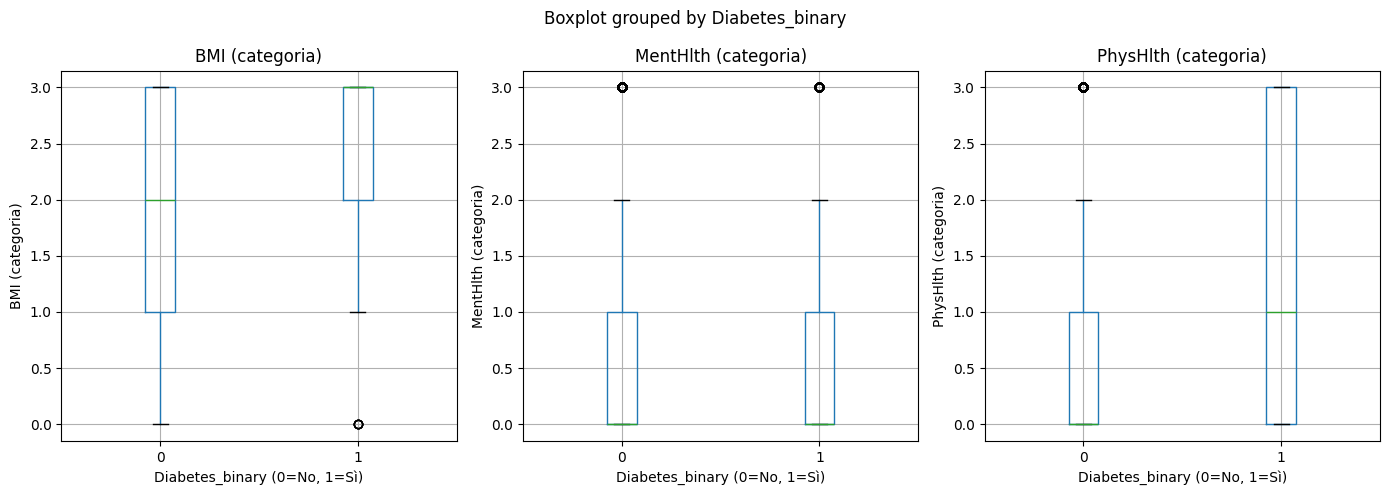

Boxplot salvato in boxplot.png


In [13]:
# -----------------------------------------------------------------------------
# 3.3 Boxplot — attributi ordinali/numerici per classe
# -----------------------------------------------------------------------------

# Riconverti le categorie in numeri per i boxplot
bmi_map      = {'sottopeso': 0, 'normale': 1, 'sovrappeso': 2, 'obeso': 3}
health_map   = {'nessuno': 0, 'lieve': 1, 'moderato': 2, 'grave': 3}

training['BMI_num']      = training['BMI_cat'].map(bmi_map)
training['MentHlth_num'] = training['MentHlth_cat'].map(health_map)
training['PhysHlth_num'] = training['PhysHlth_cat'].map(health_map)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Boxplot attributi numerici per classe', fontsize=14)

for ax, col, label in zip(axes,
                           ['BMI_num', 'MentHlth_num', 'PhysHlth_num'],
                           ['BMI (categoria)', 'MentHlth (categoria)', 'PhysHlth (categoria)']):
    training.boxplot(column=col, by='Diabetes_binary', ax=ax)
    ax.set_title(label)
    ax.set_xlabel('Diabetes_binary (0=No, 1=Sì)')
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150)
plt.show()
print("Boxplot salvato in boxplot.png")


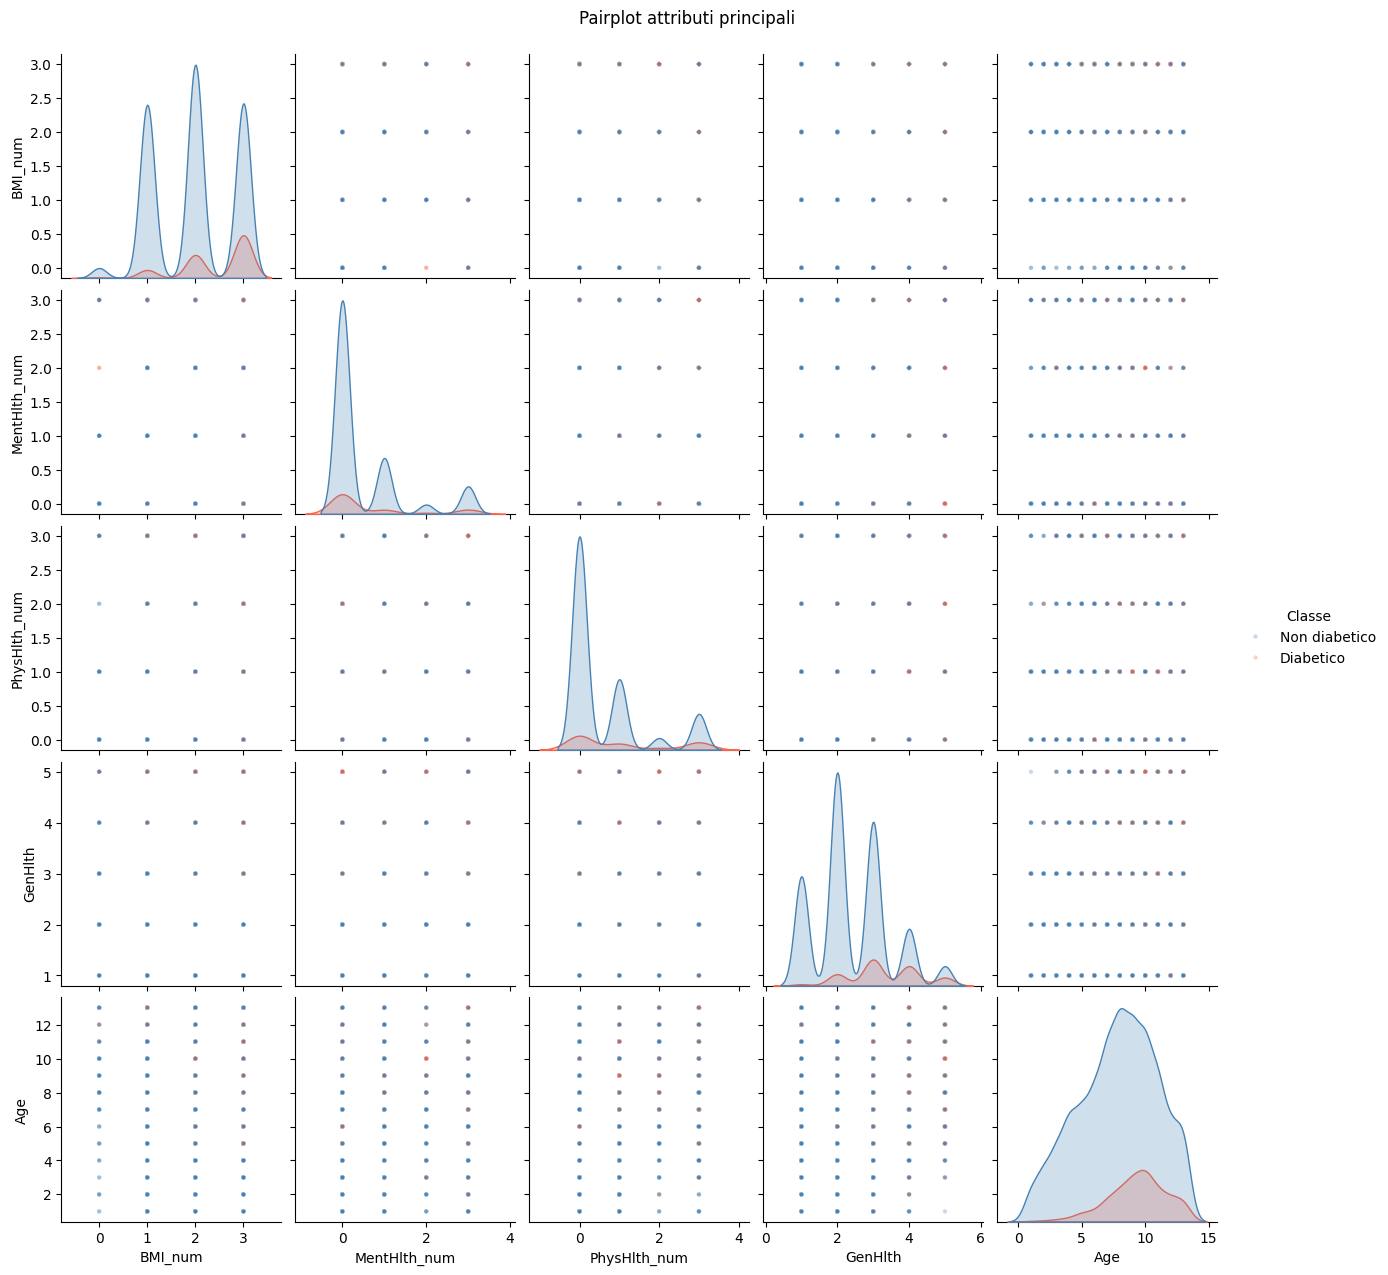

Pairplot salvato in pairplot.png


In [14]:
# -----------------------------------------------------------------------------
# 3.4 Pairplot — scatter matrix tra attributi selezionati
# -----------------------------------------------------------------------------

cols_pairplot = ['BMI_num', 'MentHlth_num', 'PhysHlth_num', 'GenHlth', 'Age', 'Diabetes_binary']

pairplot_df = training[cols_pairplot].copy()
pairplot_df['Classe'] = pairplot_df['Diabetes_binary'].map({0: 'Non diabetico', 1: 'Diabetico'})

pair_fig = sns.pairplot(pairplot_df.drop(columns=['Diabetes_binary']),
                        hue='Classe',
                        palette={'Non diabetico': 'steelblue', 'Diabetico': 'tomato'},
                        plot_kws={'alpha': 0.3, 's': 10})

pair_fig.figure.suptitle('Pairplot attributi principali', y=1.02)
pair_fig.savefig('pairplot.png', dpi=150)
plt.show()
print("Pairplot salvato in pairplot.png")


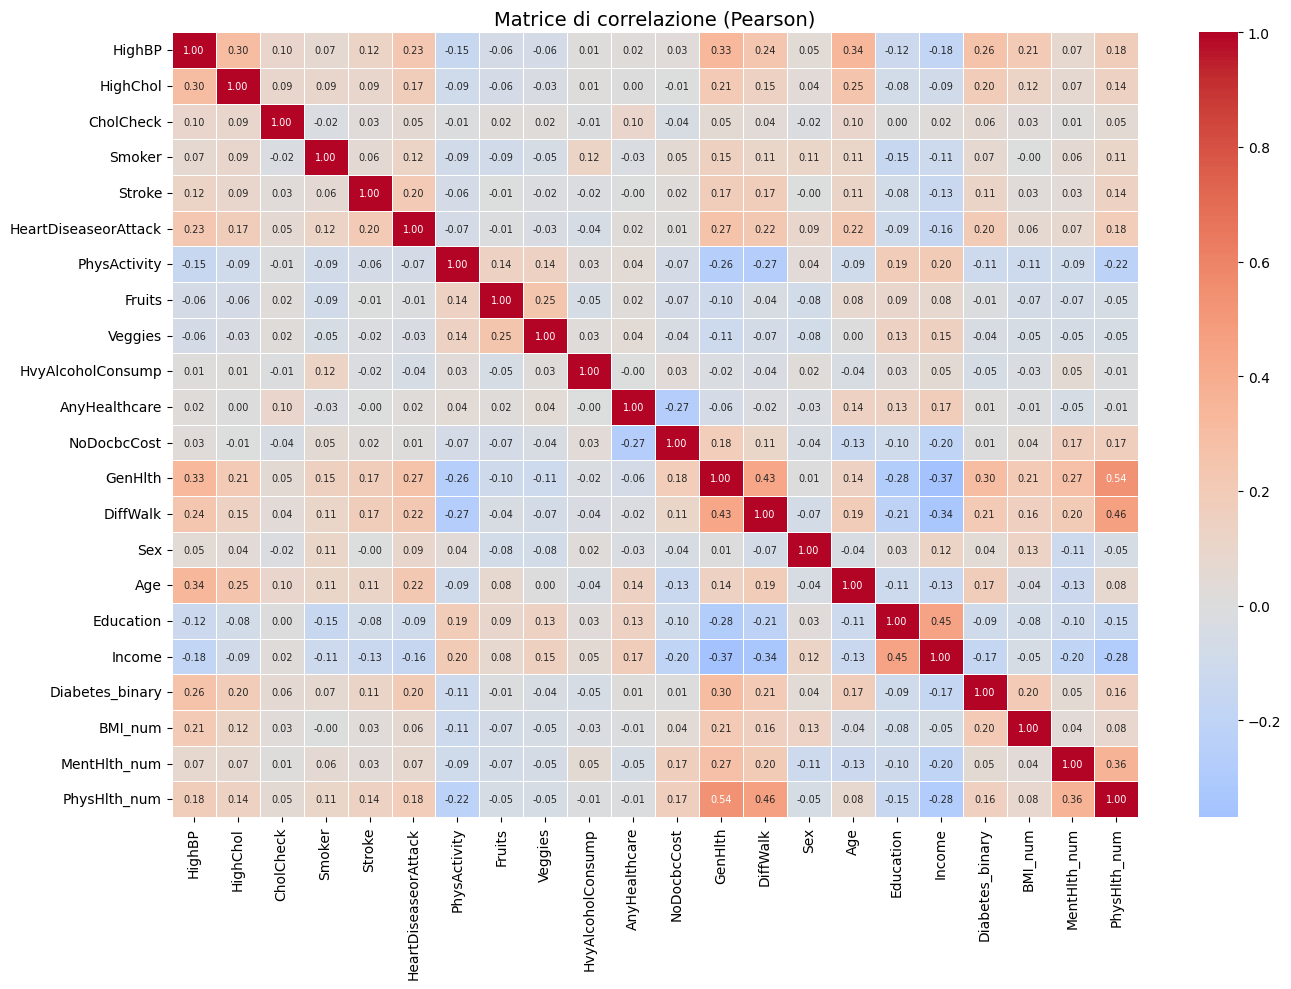

Matrice di correlazione salvata in correlazione.png

--- Correlazione con Diabetes_binary (ordinata) ---
GenHlth                 0.300
HighBP                  0.260
DiffWalk                0.207
BMI_num                 0.204
HeartDiseaseorAttack    0.198
HighChol                0.196
Age                     0.174
PhysHlth_num            0.162
Stroke                  0.115
Smoker                  0.068
CholCheck               0.063
MentHlth_num            0.053
Sex                     0.045
AnyHealthcare           0.013
NoDocbcCost             0.006
Fruits                 -0.013
Veggies                -0.040
HvyAlcoholConsump      -0.053
Education              -0.095
PhysActivity           -0.112
Income                 -0.168
Name: Diabetes_binary, dtype: float64


In [15]:
# -----------------------------------------------------------------------------
# 3.5 Matrice di correlazione con heatmap
# -----------------------------------------------------------------------------

# Converti tutte le colonne categoriche rimaste in numeriche per la correlazione
corr_df = training.drop(columns=['BMI_cat', 'MentHlth_cat', 'PhysHlth_cat'])

corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Matrice di correlazione (Pearson)', fontsize=14)
plt.tight_layout()
plt.savefig('correlazione.png', dpi=150)
plt.show()
print("Matrice di correlazione salvata in correlazione.png")

# Stampa gli attributi più correlati con il target
print("\n--- Correlazione con Diabetes_binary (ordinata) ---")
print(corr_matrix['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False).round(3))


In [16]:
# -----------------------------------------------------------------------------
# 4.1 Preparazione del dataset di training per Naïve Bayes
# -----------------------------------------------------------------------------

training = pd.read_csv('training.csv')

X_train_full = training.drop(columns=['Diabetes_binary'])
y_train_full = training['Diabetes_binary']

# Split interno 80% train / 20% test con stratificazione
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Train interno: {len(X_tr)} righe")
print(f"Test interno:  {len(X_te)} righe")

Train interno: 4000 righe
Test interno:  1000 righe


In [17]:
# -----------------------------------------------------------------------------
# 4.2 Addestramento del Naïve Bayes manuale sul train interno
# -----------------------------------------------------------------------------

# Riusiamo la stessa funzione train_naive_bayes definita nel Task 2
prior_tr, cond_tr = train_naive_bayes(X_tr, y_tr, CLASSI)


In [18]:
# -----------------------------------------------------------------------------
# 4.3 Predizione sul test interno
# -----------------------------------------------------------------------------

y_pred_te = []
for i, row in X_te.iterrows():
    pred, _ = predict_naive_bayes(row.to_dict(), prior_tr, cond_tr, CLASSI)
    y_pred_te.append(pred)

y_pred_te = pd.Series(y_pred_te, index=y_te.index)


In [19]:
# -----------------------------------------------------------------------------
# 4.4 Metriche di valutazione
# -----------------------------------------------------------------------------

TP4 = ((y_pred_te == 1) & (y_te == 1)).sum()
TN4 = ((y_pred_te == 0) & (y_te == 0)).sum()
FP4 = ((y_pred_te == 1) & (y_te == 0)).sum()
FN4 = ((y_pred_te == 0) & (y_te == 1)).sum()

accuracy4  = (TP4 + TN4) / len(y_te)
precision4 = TP4 / (TP4 + FP4) if (TP4 + FP4) > 0 else 0
recall4    = TP4 / (TP4 + FN4) if (TP4 + FN4) > 0 else 0
f1_4       = 2 * precision4 * recall4 / (precision4 + recall4) if (precision4 + recall4) > 0 else 0

print("\n--- Valutazione Naïve Bayes su training.csv (test interno 20%) ---")
print(f"Confusion matrix:  TP={TP4}  TN={TN4}  FP={FP4}  FN={FN4}")
print(f"Accuracy:   {accuracy4:.4f}")
print(f"Precision:  {precision4:.4f}")
print(f"Recall:     {recall4:.4f}")
print(f"F1-score:   {f1_4:.4f}")



--- Valutazione Naïve Bayes su training.csv (test interno 20%) ---
Confusion matrix:  TP=71  TN=755  FP=106  FN=68
Accuracy:   0.8260
Precision:  0.4011
Recall:     0.5108
F1-score:   0.4494


In [20]:
# -----------------------------------------------------------------------------
# 4.5 Ottimizzazione: feature selection basata sulla correlazione
# -----------------------------------------------------------------------------

# Seleziona solo gli attributi con correlazione assoluta > 0.1 con il target
corr_con_target = corr_df.corr()['Diabetes_binary'].drop('Diabetes_binary')
attributi_selezionati = [
    a for a in corr_con_target[corr_con_target.abs() > 0.1].index
    if a in X_tr.columns
]

print(f"\nAttributi selezionati (|corr| > 0.1): {attributi_selezionati}")

X_tr_sel = X_tr[attributi_selezionati]
X_te_sel = X_te[attributi_selezionati]

prior_sel, cond_sel = train_naive_bayes(X_tr_sel, y_tr, CLASSI)

y_pred_sel = []
for i, row in X_te_sel.iterrows():
    pred, _ = predict_naive_bayes(row.to_dict(), prior_sel, cond_sel, CLASSI)
    y_pred_sel.append(pred)

y_pred_sel = pd.Series(y_pred_sel, index=y_te.index)

TP_s = ((y_pred_sel == 1) & (y_te == 1)).sum()
TN_s = ((y_pred_sel == 0) & (y_te == 0)).sum()
FP_s = ((y_pred_sel == 1) & (y_te == 0)).sum()
FN_s = ((y_pred_sel == 0) & (y_te == 1)).sum()

accuracy_s  = (TP_s + TN_s) / len(y_te)
precision_s = TP_s / (TP_s + FP_s) if (TP_s + FP_s) > 0 else 0
recall_s    = TP_s / (TP_s + FN_s) if (TP_s + FN_s) > 0 else 0
f1_s        = 2 * precision_s * recall_s / (precision_s + recall_s) if (precision_s + recall_s) > 0 else 0

print("\n--- Naïve Bayes con feature selection (|corr| > 0.1) ---")
print(f"Confusion matrix:  TP={TP_s}  TN={TN_s}  FP={FP_s}  FN={FN_s}")
print(f"Accuracy:   {accuracy_s:.4f}")
print(f"Precision:  {precision_s:.4f}")
print(f"Recall:     {recall_s:.4f}")
print(f"F1-score:   {f1_s:.4f}")

print("\n--- Confronto con/senza feature selection ---")
print(f"{'Metrica':<12} {'Tutti gli attr':>16} {'Feature selection':>18}")
print(f"{'Accuracy':<12} {accuracy4:>16.4f} {accuracy_s:>18.4f}")
print(f"{'Precision':<12} {precision4:>16.4f} {precision_s:>18.4f}")
print(f"{'Recall':<12} {recall4:>16.4f} {recall_s:>18.4f}")
print(f"{'F1-score':<12} {f1_4:>16.4f} {f1_s:>18.4f}")



Attributi selezionati (|corr| > 0.1): ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'DiffWalk', 'Age', 'Income']

--- Naïve Bayes con feature selection (|corr| > 0.1) ---
Confusion matrix:  TP=68  TN=763  FP=98  FN=71
Accuracy:   0.8310
Precision:  0.4096
Recall:     0.4892
F1-score:   0.4459

--- Confronto con/senza feature selection ---
Metrica        Tutti gli attr  Feature selection
Accuracy               0.8260             0.8310
Precision              0.4011             0.4096
Recall                 0.5108             0.4892
F1-score               0.4494             0.4459


In [21]:
# =============================================================================
# TASK 5 — ADDESTRAMENTO CON SCIKIT-LEARN
# =============================================================================

from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import joblib

In [22]:
# -----------------------------------------------------------------------------
# 5.1 Preparazione dei dati: encoding delle colonne categoriche
# -----------------------------------------------------------------------------

training = pd.read_csv('training.csv')

# Le colonne categoriche (stringhe) vanno convertite in numeri per Scikit-Learn
cat_cols = ['BMI_cat', 'MentHlth_cat', 'PhysHlth_cat']
le = LabelEncoder()
for col in cat_cols:
    training[col] = le.fit_transform(training[col])

X = training.drop(columns=['Diabetes_binary'])
y = training['Diabetes_binary']

X_tr5, X_te5, y_tr5, y_te5 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_tr5)} righe — Test: {len(X_te5)} righe")


Train: 4000 righe — Test: 1000 righe


In [23]:
# -----------------------------------------------------------------------------
# 5.2 Definizione dei classificatori e dei loro iperparametri
# -----------------------------------------------------------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classificatori = {
    'Naïve Bayes': (
        BernoulliNB(),
        {'alpha': [0.1, 0.5, 1.0, 2.0]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
    ),
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1.0, 10.0]}
    ),
    'k-NN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 11, 21], 'metric': ['euclidean', 'manhattan']}
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
    ),
}


In [24]:
# -----------------------------------------------------------------------------
# 5.3 Addestramento con GridSearchCV e valutazione sul test set
# -----------------------------------------------------------------------------

risultati5 = []

for nome, (modello, params) in classificatori.items():
    print(f"\nAddestramento: {nome} ...")
    grid = GridSearchCV(modello, params, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_tr5, y_tr5)

    best = grid.best_estimator_
    y_pred5 = best.predict(X_te5)

    risultati5.append({
        'Modello':          nome,
        'Best params':      grid.best_params_,
        'Accuracy':         accuracy_score(y_te5, y_pred5),
        'Precision':        precision_score(y_te5, y_pred5, zero_division=0),
        'Recall':           recall_score(y_te5, y_pred5, zero_division=0),
        'F1-score':         f1_score(y_te5, y_pred5, zero_division=0),
    })



Addestramento: Naïve Bayes ...

Addestramento: Decision Tree ...

Addestramento: Logistic Regression ...

Addestramento: k-NN ...

Addestramento: Random Forest ...


In [25]:
# -----------------------------------------------------------------------------
# 5.4 Tabella comparativa dei risultati
# -----------------------------------------------------------------------------

df_risultati = pd.DataFrame(risultati5).set_index('Modello')
print("\n--- Tabella comparativa ---")
print(df_risultati[['Accuracy', 'Precision', 'Recall', 'F1-score']].round(4).to_string())

for _, row in df_risultati.iterrows():
    print(f"  {_}: {row['Best params']}")



--- Tabella comparativa ---
                     Accuracy  Precision  Recall  F1-score
Modello                                                   
Naïve Bayes             0.838     0.4034  0.3453    0.3721
Decision Tree           0.728     0.2915  0.6691    0.4061
Logistic Regression     0.728     0.3084  0.7698    0.4403
k-NN                    0.844     0.3976  0.2374    0.2973
Random Forest           0.762     0.3333  0.7122    0.4541
  Naïve Bayes: {'alpha': 0.5}
  Decision Tree: {'max_depth': 5, 'min_samples_split': 10}
  Logistic Regression: {'C': 10.0}
  k-NN: {'metric': 'manhattan', 'n_neighbors': 3}
  Random Forest: {'max_depth': 5, 'n_estimators': 100}


In [27]:
# -----------------------------------------------------------------------------
# 5.5 Salvataggio del classificatore finale (miglior F1-score)
# -----------------------------------------------------------------------------

miglior_nome = df_risultati['F1-score'].idxmax()
print(f"\nClassificatore finale selezionato: {miglior_nome}")

# Riaddestra il miglior modello su tutto il training set
miglior_params = df_risultati.loc[miglior_nome, 'Best params']
miglior_modello_base = classificatori[miglior_nome][0]
miglior_modello_base.set_params(**miglior_params)
miglior_modello_base.fit(X, y)

joblib.dump(miglior_modello_base, 'classificatore_finale.pkl')
print("Modello salvato in classificatore_finale.pkl")



Classificatore finale selezionato: Random Forest
Modello salvato in classificatore_finale.pkl
